# Lab 01: Chuẩn bị dữ liệu cho Học máy

**Mục tiêu:**
- Hiểu ý nghĩa và tầm quan trọng của giai đoạn chuẩn bị dữ liệu.
- Thực hành khám phá, làm sạch, biến đổi và chuẩn hóa dữ liệu.

**Yêu cầu:**
- Python 3.8+
- Thư viện: `numpy`, `pandas`, `scikit-learn`, `matplotlib`.
- Môi trường làm việc: **Jupyter Notebook / Google Colab / VS Code...**

## 0) Khai báo thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1) Tải dữ dữ liệu
- Tải dữ liệu từ Kaggle: [Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset) (https://www.kaggle.com/datasets/yasserh/titanic-dataset)
- Đọc dữ liệu bằng pandas.
- Hiển thị 5 dòng đầu tiên của dữ liệu.

In [3]:
data = pd.read_csv('Titanic-Dataset.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2) Xử lý dữ liệu

### 2.1) Thông tin cơ bản về dữ liệu
- Kiểm tra kích thước dữ liệu *(số dòng, số cột)*.
- Hiển thị thông tin tổng quan về dữ liệu *(tên cột, kiểu dữ liệu, giá trị null)*.
- Hiển thị thống kê mô tả các đặc trưng kiểu số *(mean, median, std, min, max)*.

In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Câu hỏi:** Từ thông tin cơ bản về dữ liệu, hãy cho biết những vấn đề nào cần được xử lý trong bước tiếp theo?

**Trả lời:
Cột 'Age', 'Cabin', 'Embarked' tồn tại missing value. Tuy nhiên, Embarked thiếu số lượng không đáng kể. Trong khi hai cột kia thiếu khá nhiều, ta sẽ xử lý dữ liệu bị thiếu ở các bước tiếp theo.**

### 2.2) Làm sạch dữ liệu
- Xử lý giá trị thiếu *(missing values)*: xác định các cột có giá trị thiếu và áp dụng các phương pháp xử lý phù hợp *(xóa bỏ, điền mean/median/mode, hoặc sử dụng mô hình dự đoán để ước lượng giá trị thiếu)*.
- Loại bỏ dữ liệu trùng lặp nếu có *(duplicate values)*.
- Xử lý dữ liệu ngoại lai nếu có *(outliers)*.

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Nhận thấy, cột embarked thiếu một số không đáng kể nên ta có thể drop**

In [6]:
data = data.dropna(subset=['Embarked'])
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

**Cột cabin chỉ thể hiện mã số cabin, ta có thể xóa hẳn cột đó vì không cần thiết. Đồng thời xóa luôn những cột không cần thiết khác ở bước này ví dụ: name, ticket, passengerId**

In [7]:
data = data.drop(columns=['Cabin', 'Ticket', 'PassengerId'])

In [8]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

In [9]:
data['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [10]:
data.duplicated().sum()
# không tồn tại dữ liệu trùng lắp

0

In [11]:
data['Embarked']
# thông tin điểm khoang tàu mà hành khách lên 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 889, dtype: object

In [12]:
df=pd.read_csv('Titanic-Dataset.csv')

Median ages (Sex x Pclass):
 Pclass     1     2     3
Sex                     
female  35.0  28.0  21.5
male    40.0  30.0  25.0


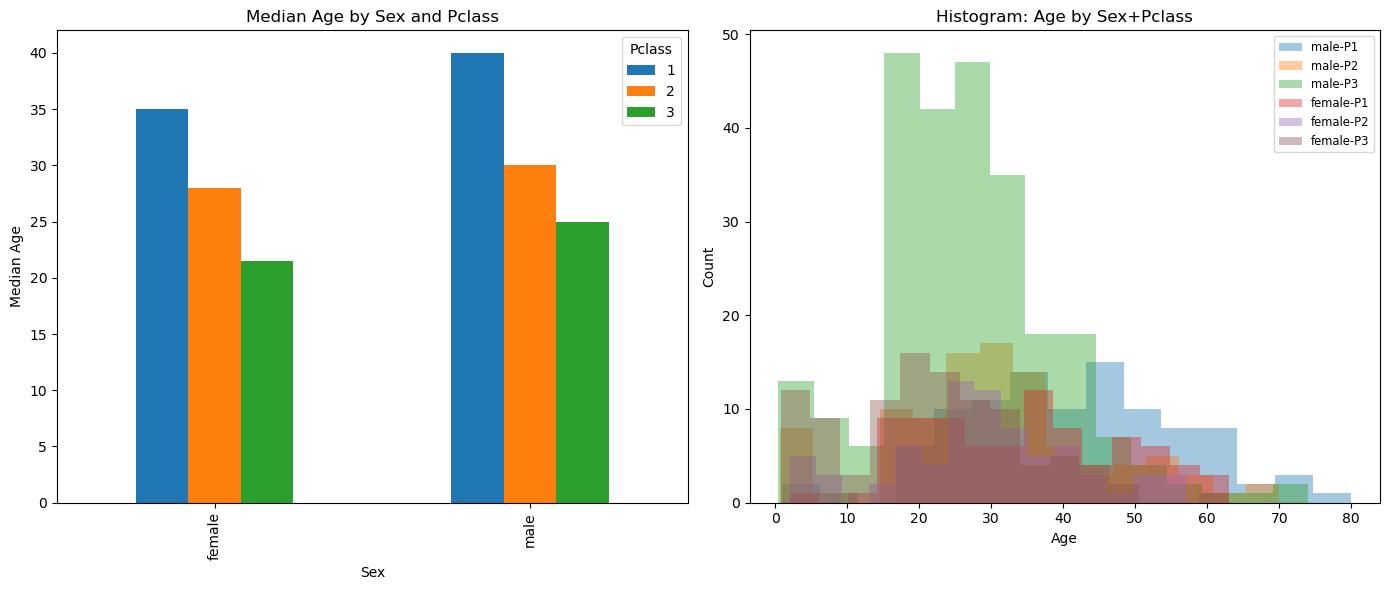

In [13]:
# cre: nhờ gpt trực quan

# --- bảng median age theo (Sex, Pclass) ---
median_ages = df.groupby(['Sex','Pclass'])['Age'].median().unstack()
print("Median ages (Sex x Pclass):\n", median_ages)

# --- dữ liệu Age không thiếu ---
age_nonnull = df[df['Age'].notnull()]
fig, axes = plt.subplots(1,2, figsize=(14,6))

# 1) Bar chart of medians
ax = axes[0]
median_ages.plot(kind='bar', ax=ax)
ax.set_title("Median Age by Sex and Pclass")
ax.set_xlabel("Sex")
ax.set_ylabel("Median Age")

# 2) Histograms of Age by group (Sex+Pclass)
ax = axes[1]
for sex in df['Sex'].unique():
    for p in sorted(df['Pclass'].unique()):
        arr = df[(df['Sex']==sex)&(df['Pclass']==p)]['Age'].dropna()
        if len(arr) > 0:
            ax.hist(arr, bins=15, alpha=0.4, label=f"{sex}-P{p}")
ax.set_title("Histogram: Age by Sex+Pclass")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(fontsize='small')

plt.tight_layout()
plt.show()


**nhận xét:
ta thấy ở histogram (median age by sex n pclass) thì tuổi trung vị càng giảm thì hạng càng giảm có thể nhận xét 
là người càng lớn tuổi thì đi hạng càng cao và tuổi của đàn ông thì thường lớn hơn phụ nữ, 
thứ 2, ở histogram (age by sex + pclass) thể hiện mỗi nhóm không chỉ khác median mà còn khác cả phân phối nữa ví dụ ở female-p3 thì có rất nhiều trẻ em/thiếu nữ nếu điền toàn bộ là meadian age của female (28) thì dẫn đến sai lệch**

In [14]:

data["AgeMissing"] = data["Age"].isnull().astype(int)

median_ages = df.groupby(["Sex", "Pclass"])["Age"].median()
def fill_age(row):
    if pd.isnull(row["Age"]):
        return median_ages[row["Sex"], row["Pclass"]]
    else:
        return row["Age"]

data["Age"] = data.apply(fill_age, axis=1)


In [15]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
AgeMissing    0
dtype: int64

In [16]:
data['Age'] = data['Age'].round(0)
# làm tròn tuổi
data['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    22.0
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64

Survived         Axes(0.125,0.653529;0.227941x0.226471)
Pclass        Axes(0.398529,0.653529;0.227941x0.226471)
Age           Axes(0.672059,0.653529;0.227941x0.226471)
SibSp            Axes(0.125,0.381765;0.227941x0.226471)
Parch         Axes(0.398529,0.381765;0.227941x0.226471)
Fare          Axes(0.672059,0.381765;0.227941x0.226471)
AgeMissing           Axes(0.125,0.11;0.227941x0.226471)
dtype: object

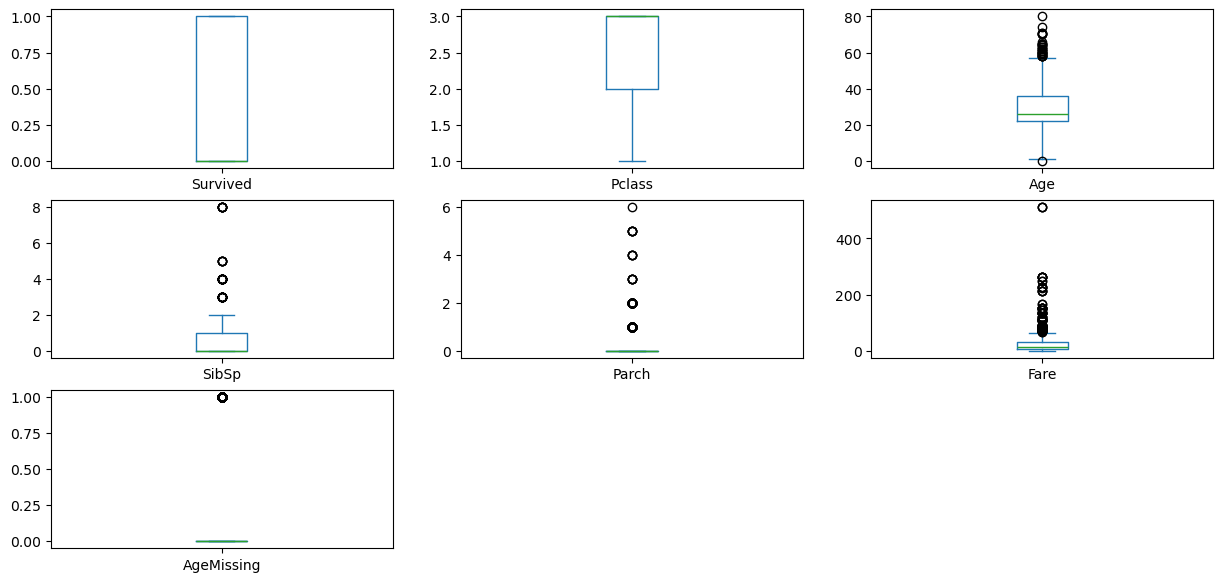

In [17]:
data.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,7))

**XỬ LÝ OUTLIER Ở AGE VÀ FARE**

In [18]:
# Tính IQR
IQR = data["Age"].quantile(0.75) - data["Age"].quantile(0.25)
lower_age_limit = data["Age"].quantile(0.25) - (IQR * 1.5)
upper_age_limit = data["Age"].quantile(0.75) + (IQR * 1.5)

print("Giới hạn dưới:", lower_age_limit)
print("Giới hạn trên:", upper_age_limit)

Giới hạn dưới: 1.0
Giới hạn trên: 57.0


(889, 10) (856, 10)


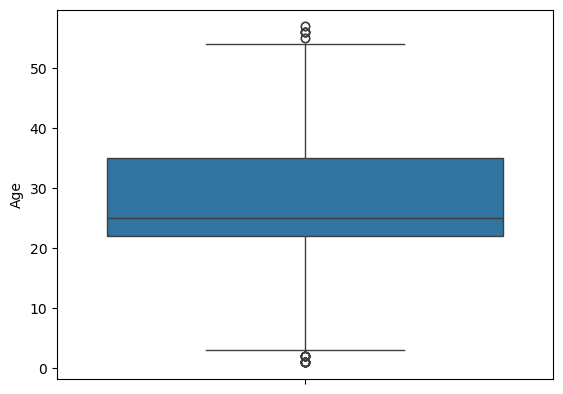

In [19]:
# Xác định chỉ số dòng chứa outlier
age_outliers = np.where(
    (data["Age"] > upper_age_limit) |
    (data["Age"] < lower_age_limit),
    True, False
)
# Loại bỏ các outlier 
titanic_without_age_outliers = data.loc[~(age_outliers), :]
print(data.shape, titanic_without_age_outliers.shape)

# Gán lại data đã loại outlier
data = titanic_without_age_outliers

# Trực quan lại với boxplot
sns.boxplot(y='Age', data=data)
plt.show()

In [20]:
IQR = data["Fare"].quantile(0.75) - data["Fare"].quantile(0.25)
lower_fare_limit = data["Fare"].quantile(0.25) - (IQR * 1.5)
upper_fare_limit = data["Fare"].quantile(0.75) + (IQR * 1.5)

print(lower_fare_limit)
print(upper_fare_limit)

-26.0105
64.4063


/var/folders/js/n56324115jgg31l7zxvkc74m0000gn/T/ipykernel_15879/1670735902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Fare"] = np.where(
/var/folders/js/n56324115jgg31l7zxvkc74m0000gn/T/ipykernel_15879/1670735902.py:5: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr).nonzero()` if the old behavior was intended.
  data["Fare"] = np.where(sns.boxplot(y='Fare', data=data))


ValueError: Length of values (1) does not match length of index (856)

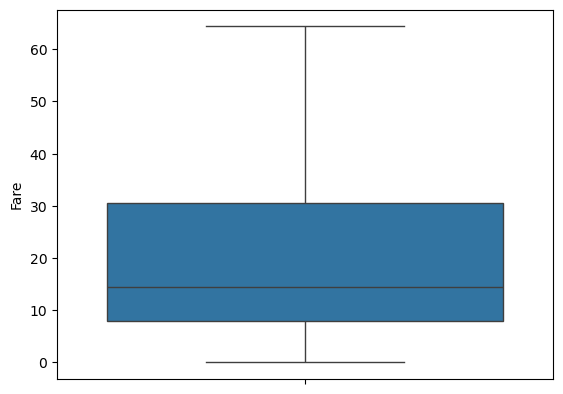

In [21]:
data["Fare"] = np.where(
    data["Fare"] > upper_fare_limit, upper_fare_limit,
    np.where(data["Fare"] < lower_fare_limit, lower_fare_limit, data["Fare"])
)
data["Fare"] = np.where(sns.boxplot(y='Fare', data=data))
plt.show()

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 856 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    856 non-null    int64  
 1   Pclass      856 non-null    int64  
 2   Name        856 non-null    object 
 3   Sex         856 non-null    object 
 4   Age         856 non-null    float64
 5   SibSp       856 non-null    int64  
 6   Parch       856 non-null    int64  
 7   Fare        856 non-null    float64
 8   Embarked    856 non-null    object 
 9   AgeMissing  856 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 73.6+ KB


### 2.3) Biến đổi dữ liệu
- Mã hóa biến phân loại *(One-Hot Encoding, Label Encoding)*.
- Chuẩn hóa/tiêu chuẩn hóa biến số *(Min-Max Scaling, Standardization)*.

**Câu hỏi:** Thử dùng OrdinalEncoder cho một cột có thứ tự và giải thích khi nào nên dùng Ordinal thay vì One-Hot.

**Trả lời: 
ordinal thích hợp cho các nhãn có thứ bậc ví dụ như trình độ, bằng cấp còn one hot thích hợp cho các nhãn không có thứ ví dụ như màu sắc, các loại trong một trường nào đó (các ngành trong khoa). Nhưng trong trường hợp biến phân loại quá nhiều sẽ gây tăng số chiều của mảng -> tốn bộ nhớ**

In [23]:
data['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [24]:
# label encoding
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

In [25]:
# one hot encoding
data = pd.get_dummies(data, columns=['Embarked'], drop_first=False)
print(data.head())

   Survived  Pclass                                               Name  Sex  \
0         0       3                            Braund, Mr. Owen Harris    0   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1   
2         1       3                             Heikkinen, Miss. Laina    1   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1   
4         0       3                           Allen, Mr. William Henry    0   

    Age  SibSp  Parch     Fare  AgeMissing  Embarked_C  Embarked_Q  Embarked_S  
0  22.0      1      0   7.2500           0       False       False        True  
1  38.0      1      0  64.4063           0        True       False       False  
2  26.0      0      0   7.9250           0       False       False        True  
3  35.0      1      0  53.1000           0       False       False        True  
4  35.0      0      0   8.0500           0       False       False        True  
